DB 연결 성공
라이브러리 임포트 완료
데이터 추출 함수 정의 완료
[FETCH] 수출 데이터: hs_code=8542, indicator=expDlr
[FETCH]   -> 60행  2011-03-31 ~ 2025-12-31
[FETCH] 재무 데이터: ticker=005930, indicator=매출액(천원)
[FETCH]   -> 58행  2011-03-31 ~ 2025-06-30
[MERGE] 결합 후 58행

[데이터 미리보기 (최근 8행)]
  [레벨 회귀]  Y=매출 레벨  ~  X=수출 레벨  (N=58)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     203.8
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.59e-20
Time:                        00:32:27   Log-Likelihood:                -1377.0
No. Observations:                  58   AIC:                             2758.
Df Residuals:                      56   BIC:                             2762.
Df Model:                           1                                     

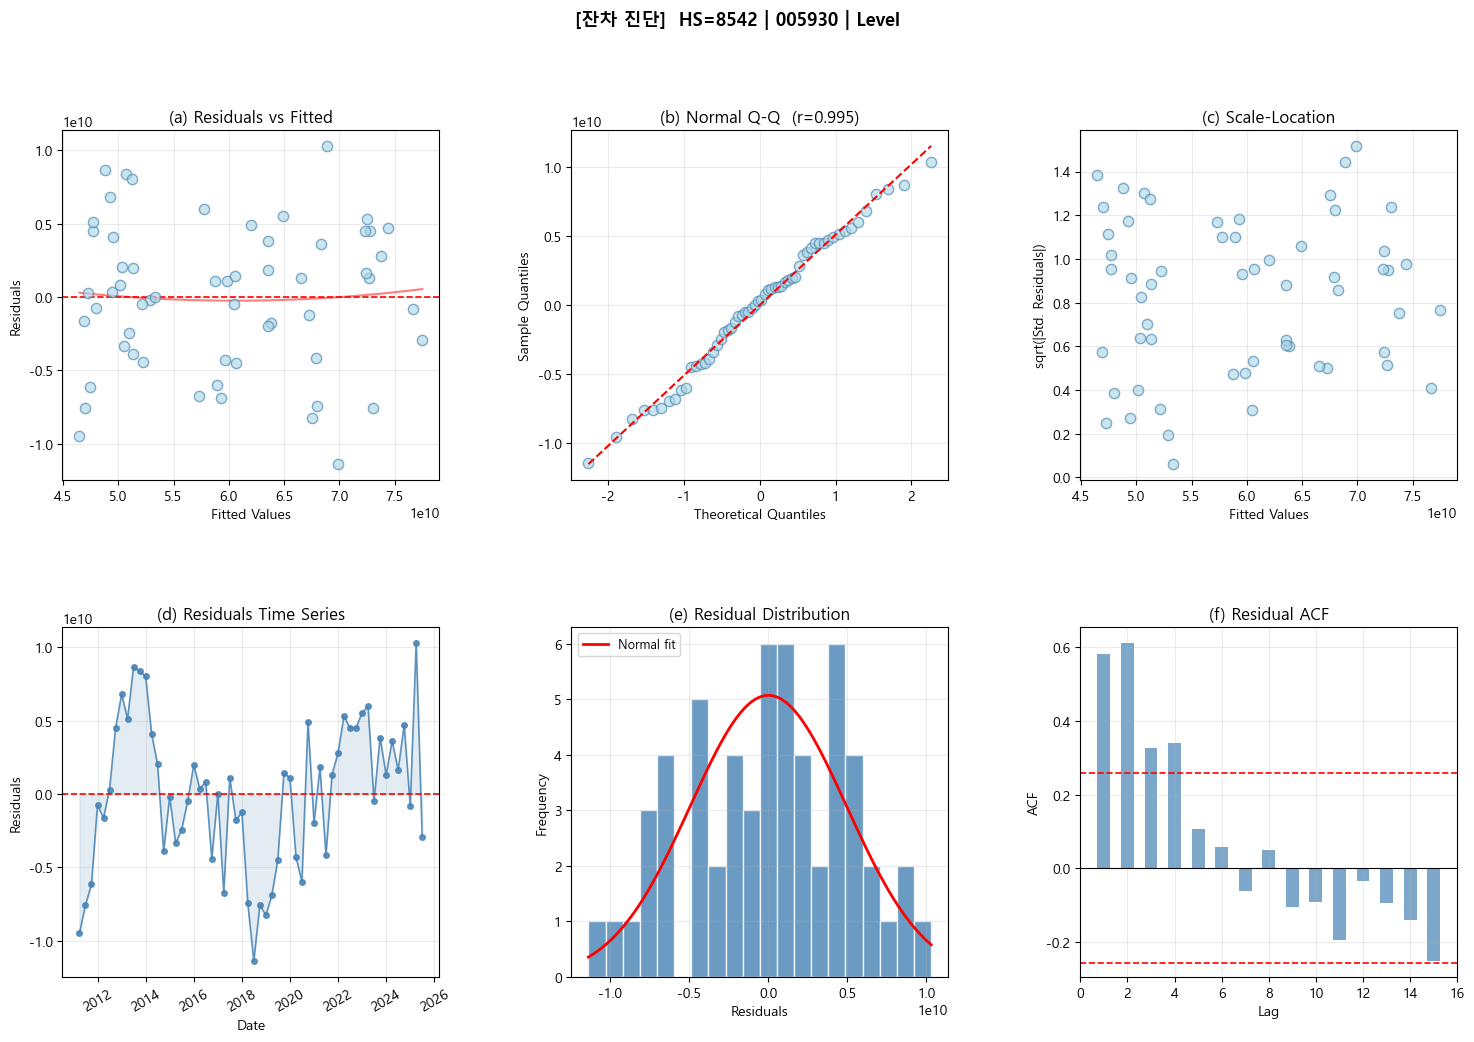

  [저장] C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\analysis\한국기업_매출예측\resid_yoy_8542_005930.png


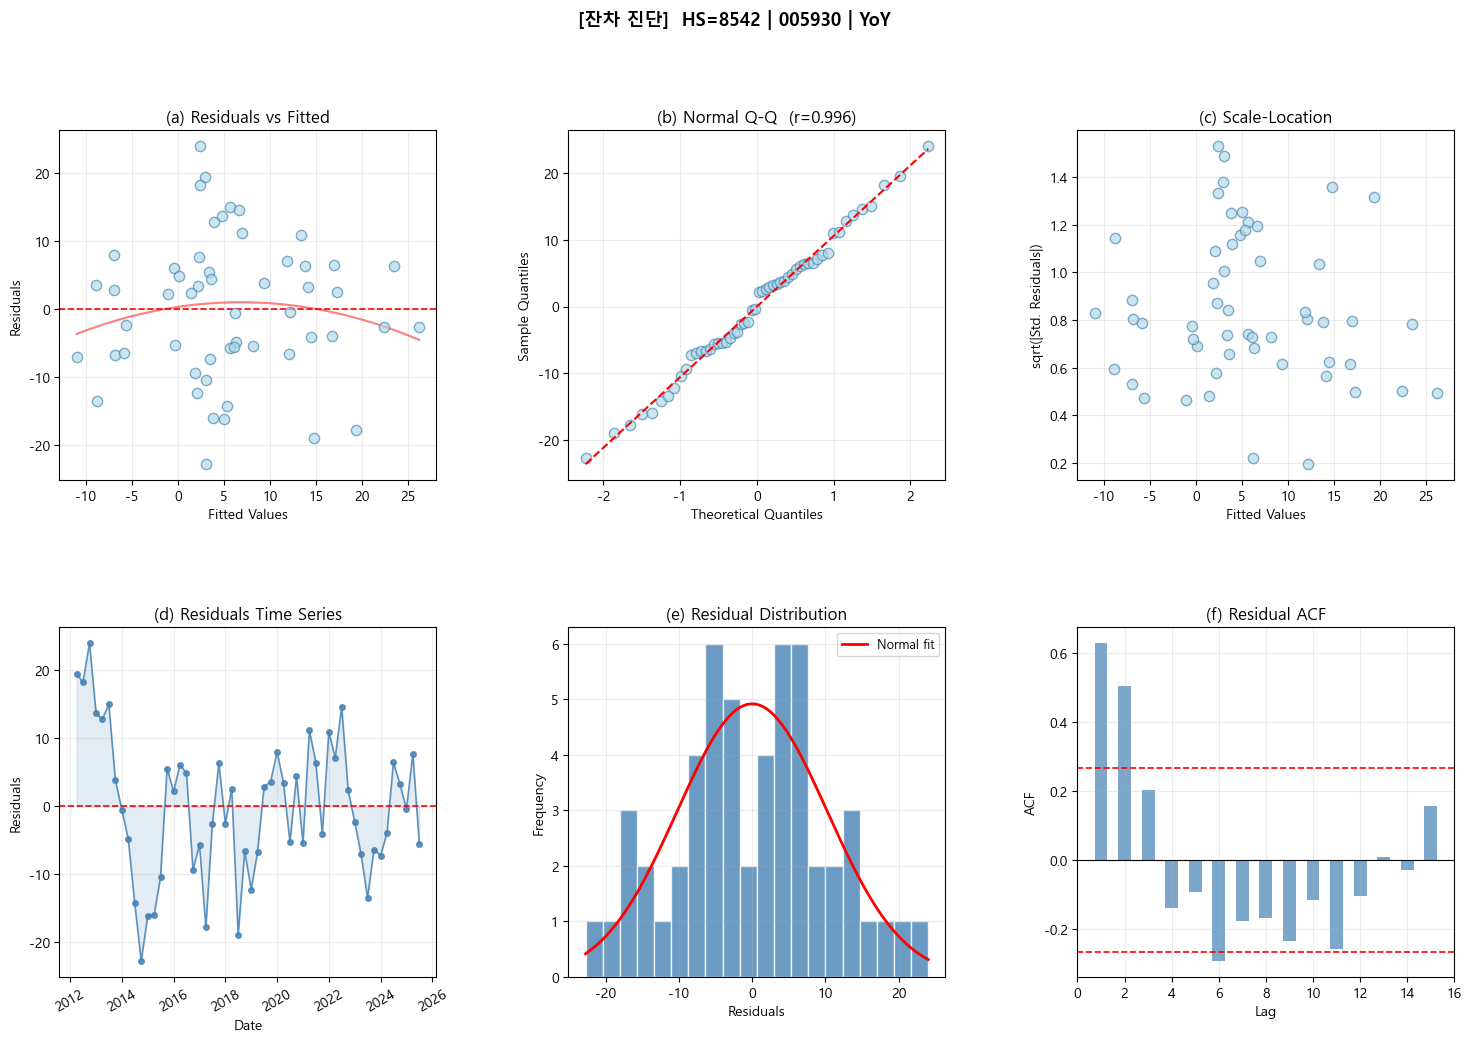

산점도 함수 정의 완료
  [저장] C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\analysis\한국기업_매출예측\scatter_level_8542_005930.png


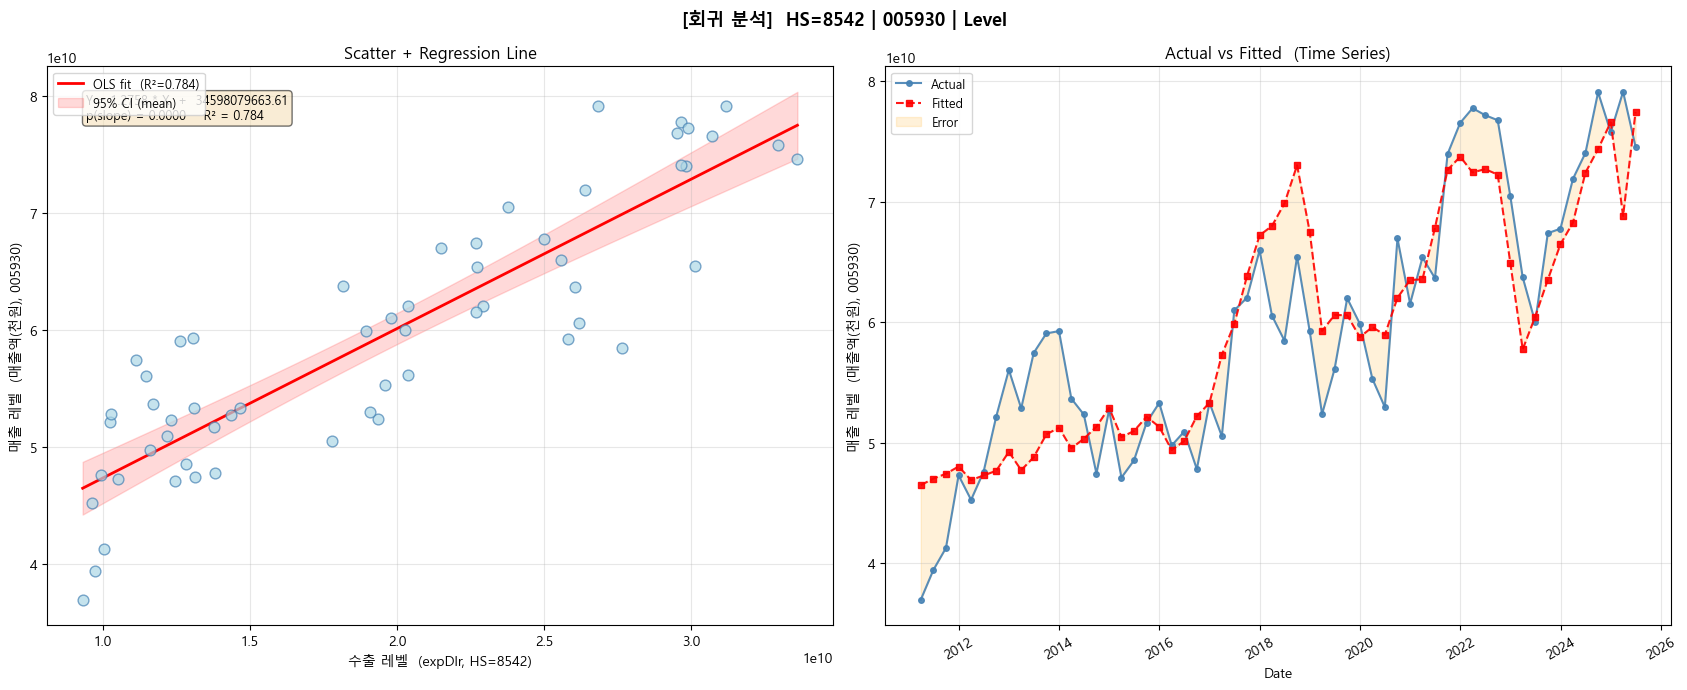

  [저장] C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\Korea_Market\analysis\한국기업_매출예측\scatter_yoy_8542_005930.png


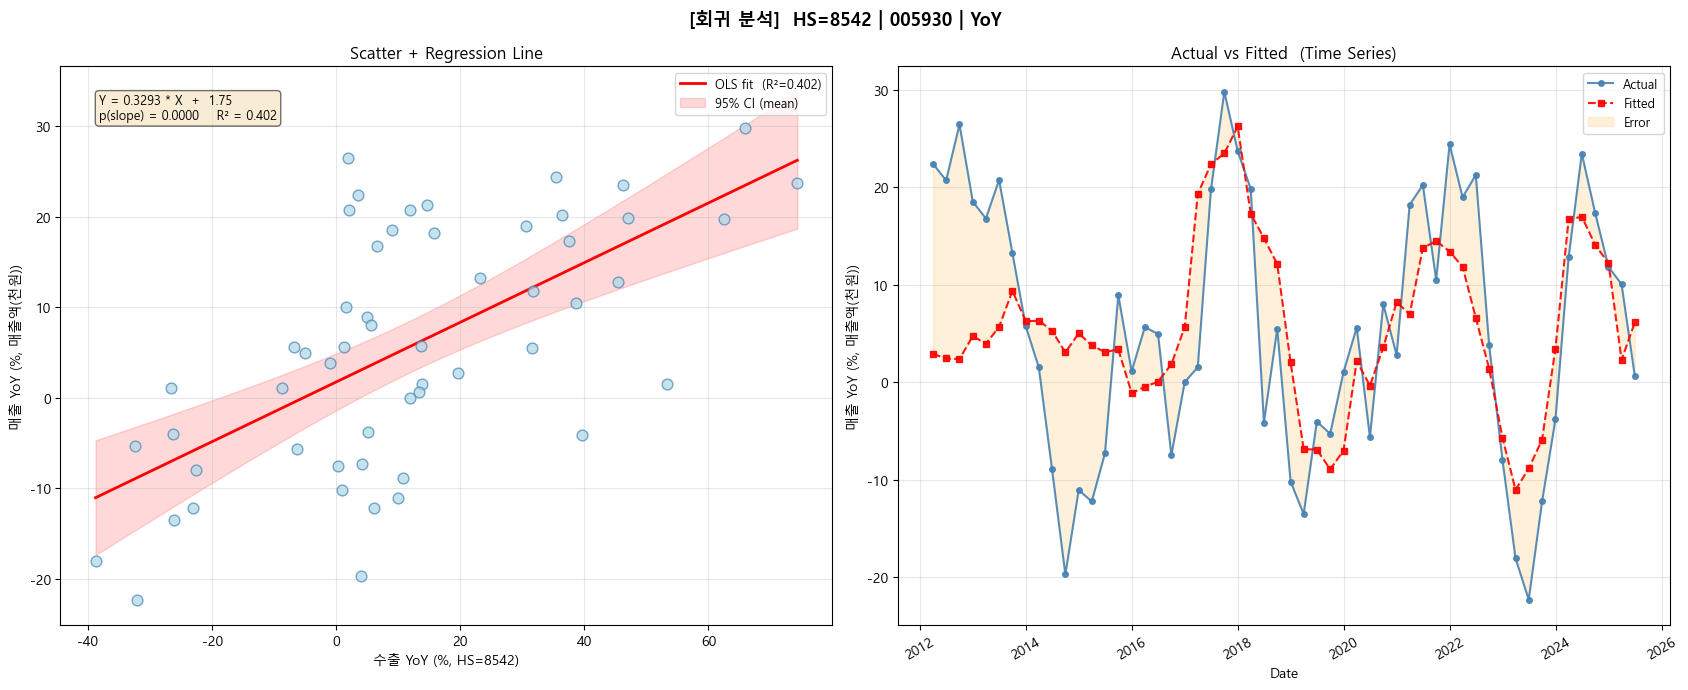


모든 분석 완료


In [1]:
# -*- coding: utf-8 -*-
# ============================================================
#  HS Code 수출 vs 기업 매출 회귀분석
#  실행 환경 : PyCharm / 로컬 Jupyter
#  노트북 위치 :
#    C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
#    \Korea_Market\analysis\한국기업_매출예측\수출증가_매출증가_회귀분석.ipynb
#  config.py 위치 :
#    C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
#    \DATA\config.py
# ============================================================


# ─────────────────────────────────────────────
# [셀 1] 경로 설정 및 config 로드
# ─────────────────────────────────────────────
import sys
import os

# config.py 가 있는 디렉토리를 sys.path 에 추가
CONFIG_DIR = r'C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA'
sys.path.insert(0, CONFIG_DIR)

from config import get_engine, get_db_info, log

db_info = get_db_info()
engine  = get_engine(db_info)

# DB 연결 확인
from sqlalchemy import text
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("DB 연결 성공")


# ─────────────────────────────────────────────
# [셀 2] 라이브러리 임포트 및 한글 폰트 설정
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Windows 한글 폰트
plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 임포트 완료")


# ─────────────────────────────────────────────
# [셀 3] 분석 파라미터  ← 여기만 수정하세요
# ─────────────────────────────────────────────
HS_CODE          = '8542'        # HS 코드 (예: 반도체 8542)
TICKER           = '005930'      # 종목코드 (예: 삼성전자 005930)
INDICATOR        = '매출액(천원)'  # 재무 지표명
EXPORT_INDICATOR = 'expDlr'      # balPayments / expDlr / impDlr
START_DATE       = '2011-01-01'
END_DATE         = None          # None 이면 오늘까지

SAVE_FIGURES     = True
# PNG 저장 위치 = 노트북과 같은 폴더
SAVE_DIR = os.path.dirname(os.path.abspath('수출증가_매출증가_회귀분석.ipynb'))


# ─────────────────────────────────────────────
# [셀 4] 데이터 추출 함수
# ─────────────────────────────────────────────
def fetch_trade_data(hs_code, export_indicator, start_date, end_date=None):
    """korea_quarterly_trade_data → HS code 수출 시계열"""
    if end_date is None:
        end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    query = f"""
        SELECT date, value
        FROM   korea_quarterly_trade_data
        WHERE  root_hs_code = '{hs_code}'
          AND  indicator    = '{export_indicator}'
          AND  date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY date
    """
    df = pd.read_sql(query, engine, parse_dates=['date'])
    if df.empty:
        raise ValueError(f"데이터 없음: hs_code={hs_code}, indicator={export_indicator}")
    s = df.set_index('date')['value'].rename(export_indicator)
    s.index = pd.to_datetime(s.index).to_period('Q').to_timestamp('Q')
    return s.sort_index()


def fetch_financial_data(ticker, indicator, start_date, end_date=None):
    """korea_fs_data_from_DG → ticker + indicator 시계열"""
    if end_date is None:
        end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
    query = f"""
        SELECT date, value
        FROM   korea_fs_data_from_DG
        WHERE  ticker    = '{ticker}'
          AND  indicator = '{indicator}'
          AND  date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY date
    """
    df = pd.read_sql(query, engine, parse_dates=['date'])
    if df.empty:
        raise ValueError(f"데이터 없음: ticker={ticker}, indicator={indicator}")
    s = df.set_index('date')['value'].rename(indicator)
    s.index = pd.to_datetime(s.index).to_period('Q').to_timestamp('Q')
    return s.sort_index()


print("데이터 추출 함수 정의 완료")


# ─────────────────────────────────────────────
# [셀 5] 데이터 추출 + 결합 + YoY 계산
# ─────────────────────────────────────────────
log('FETCH', f"수출 데이터: hs_code={HS_CODE}, indicator={EXPORT_INDICATOR}")
trade_s = fetch_trade_data(HS_CODE, EXPORT_INDICATOR, START_DATE, END_DATE)
log('FETCH', f"  -> {len(trade_s)}행  {trade_s.index[0].date()} ~ {trade_s.index[-1].date()}")

log('FETCH', f"재무 데이터: ticker={TICKER}, indicator={INDICATOR}")
fin_s = fetch_financial_data(TICKER, INDICATOR, START_DATE, END_DATE)
log('FETCH', f"  -> {len(fin_s)}행  {fin_s.index[0].date()} ~ {fin_s.index[-1].date()}")

# inner join
df = pd.concat([trade_s, fin_s], axis=1).dropna()
df.index.name = 'date'
log('MERGE', f"결합 후 {len(df)}행")

# YoY (분기 기준 4기 전 대비)
df['export_yoy']  = df[EXPORT_INDICATOR].pct_change(4) * 100
df['revenue_yoy'] = df[INDICATOR].pct_change(4) * 100

print("\n[데이터 미리보기 (최근 8행)]")
df.tail(8)


# ─────────────────────────────────────────────
# [셀 6] 회귀분석 — 레벨
# ─────────────────────────────────────────────
df_level = df[[EXPORT_INDICATOR, INDICATOR]].dropna()

X_lv = sm.add_constant(df_level[EXPORT_INDICATOR].values)
Y_lv = df_level[INDICATOR].values

model_level = sm.OLS(Y_lv, X_lv).fit()

dw_lv                      = durbin_watson(model_level.resid)
bp_stat_lv, bp_p_lv, _, _  = het_breuschpagan(model_level.resid, X_lv)

print("=" * 62)
print(f"  [레벨 회귀]  Y=매출 레벨  ~  X=수출 레벨  (N={len(df_level)})")
print("=" * 62)
print(model_level.summary())
print(f"\n  Durbin-Watson   : {dw_lv:.4f}  (2 근처 = 자기상관 없음)")
print(f"  Breusch-Pagan p : {bp_p_lv:.4f}  "
      f"({'이분산 의심' if bp_p_lv < 0.05 else '등분산 가정 유지'})")


# ─────────────────────────────────────────────
# [셀 7] 회귀분석 — YoY
# ─────────────────────────────────────────────
df_yoy = df[['export_yoy', 'revenue_yoy']].dropna()

X_yy = sm.add_constant(df_yoy['export_yoy'].values)
Y_yy = df_yoy['revenue_yoy'].values

model_yoy = sm.OLS(Y_yy, X_yy).fit()

dw_yy                      = durbin_watson(model_yoy.resid)
bp_stat_yy, bp_p_yy, _, _  = het_breuschpagan(model_yoy.resid, X_yy)

print("=" * 62)
print(f"  [YoY 회귀]  Y=매출 YoY  ~  X=수출 YoY  (N={len(df_yoy)})")
print("=" * 62)
print(model_yoy.summary())
print(f"\n  Durbin-Watson   : {dw_yy:.4f}  (2 근처 = 자기상관 없음)")
print(f"  Breusch-Pagan p : {bp_p_yy:.4f}  "
      f"({'이분산 의심' if bp_p_yy < 0.05 else '등분산 가정 유지'})")


# ─────────────────────────────────────────────
# [셀 8] 잔차 진단 시각화 함수 정의
# ─────────────────────────────────────────────
def plot_residuals(model, x_series, title_prefix, save_path=None):
    fitted    = model.fittedvalues
    resid     = model.resid
    std_resid = resid / resid.std()
    n         = len(resid)

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(f"[잔차 진단]  {title_prefix}",
                 fontsize=13, fontweight='bold', y=0.99)
    gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    # (a) Residuals vs Fitted
    ax = fig.add_subplot(gs[0, 0])
    ax.scatter(fitted, resid, alpha=0.65, edgecolors='steelblue',
               facecolors='lightblue', s=55, zorder=3)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    z  = np.polyfit(fitted, resid, 2)
    xr = np.linspace(fitted.min(), fitted.max(), 200)
    ax.plot(xr, np.polyval(z, xr), 'r-', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Fitted Values'); ax.set_ylabel('Residuals')
    ax.set_title('(a) Residuals vs Fitted'); ax.grid(True, alpha=0.25)

    # (b) Normal Q-Q
    ax = fig.add_subplot(gs[0, 1])
    (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.65, edgecolors='steelblue',
               facecolors='lightblue', s=55)
    ax.plot(osm, np.array(osm) * slope + intercept, 'r--', linewidth=1.5)
    ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'(b) Normal Q-Q  (r={r:.3f})'); ax.grid(True, alpha=0.25)

    # (c) Scale-Location
    ax = fig.add_subplot(gs[0, 2])
    ax.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.65,
               edgecolors='steelblue', facecolors='lightblue', s=55)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('sqrt(|Std. Residuals|)')
    ax.set_title('(c) Scale-Location'); ax.grid(True, alpha=0.25)

    # (d) 잔차 시계열
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(x_series.index, resid, marker='o', markersize=4,
            linewidth=1.2, color='steelblue', alpha=0.85)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax.fill_between(x_series.index, resid, 0, alpha=0.15, color='steelblue')
    ax.set_xlabel('Date'); ax.set_ylabel('Residuals')
    ax.set_title('(d) Residuals Time Series')
    ax.tick_params(axis='x', rotation=30); ax.grid(True, alpha=0.25)

    # (e) 잔차 히스토그램
    ax = fig.add_subplot(gs[1, 1])
    ax.hist(resid, bins=20, edgecolor='white', color='steelblue', alpha=0.8)
    xr2 = np.linspace(resid.min(), resid.max(), 300)
    pdf = (stats.norm.pdf(xr2, resid.mean(), resid.std())
           * n * (resid.max() - resid.min()) / 20)
    ax.plot(xr2, pdf, 'r-', linewidth=2, label='Normal fit')
    ax.set_xlabel('Residuals'); ax.set_ylabel('Frequency')
    ax.set_title('(e) Residual Distribution')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

    # (f) 잔차 ACF
    ax = fig.add_subplot(gs[1, 2])
    lags     = range(1, min(16, n // 2))
    acf_vals = [pd.Series(resid).autocorr(lag=l) for l in lags]
    conf     = 1.96 / np.sqrt(n)
    ax.bar(list(lags), acf_vals, color='steelblue', alpha=0.7, width=0.55)
    ax.axhline( conf, color='red', linestyle='--', linewidth=1.2)
    ax.axhline(-conf, color='red', linestyle='--', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag'); ax.set_ylabel('ACF')
    ax.set_title('(f) Residual ACF'); ax.grid(True, alpha=0.25)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  [저장] {save_path}")
    plt.show()

print("잔차 진단 함수 정의 완료")


# ─────────────────────────────────────────────
# [셀 9] 잔차 진단 — 레벨
# ─────────────────────────────────────────────
plot_residuals(
    model_level,
    df_level[EXPORT_INDICATOR],
    title_prefix=f"HS={HS_CODE} | {TICKER} | Level",
    save_path=os.path.join(SAVE_DIR, f'resid_level_{HS_CODE}_{TICKER}.png') if SAVE_FIGURES else None,
)


# ─────────────────────────────────────────────
# [셀 10] 잔차 진단 — YoY
# ─────────────────────────────────────────────
plot_residuals(
    model_yoy,
    df_yoy['export_yoy'],
    title_prefix=f"HS={HS_CODE} | {TICKER} | YoY",
    save_path=os.path.join(SAVE_DIR, f'resid_yoy_{HS_CODE}_{TICKER}.png') if SAVE_FIGURES else None,
)


# ─────────────────────────────────────────────
# [셀 11] XY 산점도 + 회귀선 함수 정의
# ─────────────────────────────────────────────
def plot_scatter_regression(model, x_series, y_series,
                            label_x, label_y, title_prefix,
                            save_path=None):
    fitted = model.fittedvalues
    r2     = model.rsquared
    params = model.params
    pvals  = model.pvalues
    xvals  = x_series.values
    yvals  = y_series.values
    n      = len(xvals)

    x_line  = np.linspace(xvals.min(), xvals.max(), 300)
    y_line  = params[0] + params[1] * x_line

    x_mean  = xvals.mean()
    se_fit  = model.mse_resid ** 0.5
    t_crit  = stats.t.ppf(0.975, df=n - 2)
    se_band = se_fit * np.sqrt(
        1 / n + (x_line - x_mean) ** 2 / ((xvals - x_mean) ** 2).sum()
    )
    y_upper = y_line + t_crit * se_band
    y_lower = y_line - t_crit * se_band

    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    fig.suptitle(f"[회귀 분석]  {title_prefix}", fontsize=13, fontweight='bold')

    # 왼쪽: 산점도 + 회귀선
    ax = axes[0]
    ax.scatter(xvals, yvals, alpha=0.7, edgecolors='steelblue',
               facecolors='lightblue', s=60, zorder=3)
    ax.plot(x_line, y_line, 'r-', linewidth=2,
            label=f'OLS fit  (R²={r2:.3f})')
    ax.fill_between(x_line, y_lower, y_upper, alpha=0.15,
                    color='red', label='95% CI (mean)')
    if n <= 40:
        for xi, yi, di in zip(xvals, yvals, x_series.index):
            ax.annotate(str(di)[:7], (xi, yi), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')
    eq_str = (f"Y = {params[1]:.4f} * X  +  {params[0]:.2f}\n"
              f"p(slope) = {pvals[1]:.4f}    R² = {r2:.3f}")
    ax.text(0.05, 0.95, eq_str, transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.55))
    ax.set_xlabel(label_x); ax.set_ylabel(label_y)
    ax.set_title('Scatter + Regression Line')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # 오른쪽: Actual vs Fitted 시계열
    ax2 = axes[1]
    ax2.plot(x_series.index, yvals, 'o-', color='steelblue',
             markersize=4, linewidth=1.5, alpha=0.9, label='Actual')
    ax2.plot(x_series.index, fitted, 's--', color='red',
             markersize=4, linewidth=1.5, alpha=0.9, label='Fitted')
    ax2.fill_between(x_series.index, yvals, fitted,
                     alpha=0.15, color='orange', label='Error')
    ax2.set_xlabel('Date'); ax2.set_ylabel(label_y)
    ax2.set_title('Actual vs Fitted  (Time Series)')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  [저장] {save_path}")
    plt.show()

print("산점도 함수 정의 완료")


# ─────────────────────────────────────────────
# [셀 12] XY 산점도 — 레벨
# ─────────────────────────────────────────────
plot_scatter_regression(
    model_level,
    df_level[EXPORT_INDICATOR],
    df_level[INDICATOR],
    label_x=f"수출 레벨  ({EXPORT_INDICATOR}, HS={HS_CODE})",
    label_y=f"매출 레벨  ({INDICATOR}, {TICKER})",
    title_prefix=f"HS={HS_CODE} | {TICKER} | Level",
    save_path=os.path.join(SAVE_DIR, f'scatter_level_{HS_CODE}_{TICKER}.png') if SAVE_FIGURES else None,
)


# ─────────────────────────────────────────────
# [셀 13] XY 산점도 — YoY
# ─────────────────────────────────────────────
plot_scatter_regression(
    model_yoy,
    df_yoy['export_yoy'],
    df_yoy['revenue_yoy'],
    label_x=f"수출 YoY (%, HS={HS_CODE})",
    label_y=f"매출 YoY (%, {INDICATOR})",
    title_prefix=f"HS={HS_CODE} | {TICKER} | YoY",
    save_path=os.path.join(SAVE_DIR, f'scatter_yoy_{HS_CODE}_{TICKER}.png') if SAVE_FIGURES else None,
)

print("\n모든 분석 완료")